# Notebook 01 — Randles baseline spectra

Generate and visualise synthetic EIS spectra for a healthy iridium anode
in a molten iron-oxide bath at ~1600 °C.

**What this shows:** the Randles equivalent circuit (Rs — [Rct + W] ║ Cdl)
produces the characteristic features of a real EIS spectrum:
- A depressed semicircle in the Nyquist plot (charge-transfer arc)
- A 45° Warburg tail at low frequencies (diffusion)
- Bode magnitude rising at low frequency, phase peaking near the RC corner

**What this does not show:** real measured data; thermal noise behaviour;
multi-layer oxide effects; convection in the melt.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from randles_model import (
    moe_anode_baseline,
    moe_frequencies,
    randles_impedance,
    add_noise,
    nyquist_arrays,
    bode_arrays,
    RandlesParams,
)

Matplotlib is building the font cache; this may take a moment.


In [2]:
baseline = moe_anode_baseline()
print("Baseline parameters:")
for k, v in baseline.to_dict().items():
    print(f"  {k:8s} = {v:.4g}")

freqs = moe_frequencies(n_per_decade=12)
Z_clean = randles_impedance(baseline, freqs)

rng = np.random.default_rng(0)
Z_noisy = add_noise(Z_clean, snr_db=40, rng=rng)

Baseline parameters:
  Rs       = 1.2
  Rct      = 8
  Cdl      = 0.00025
  sigma    = 3.5


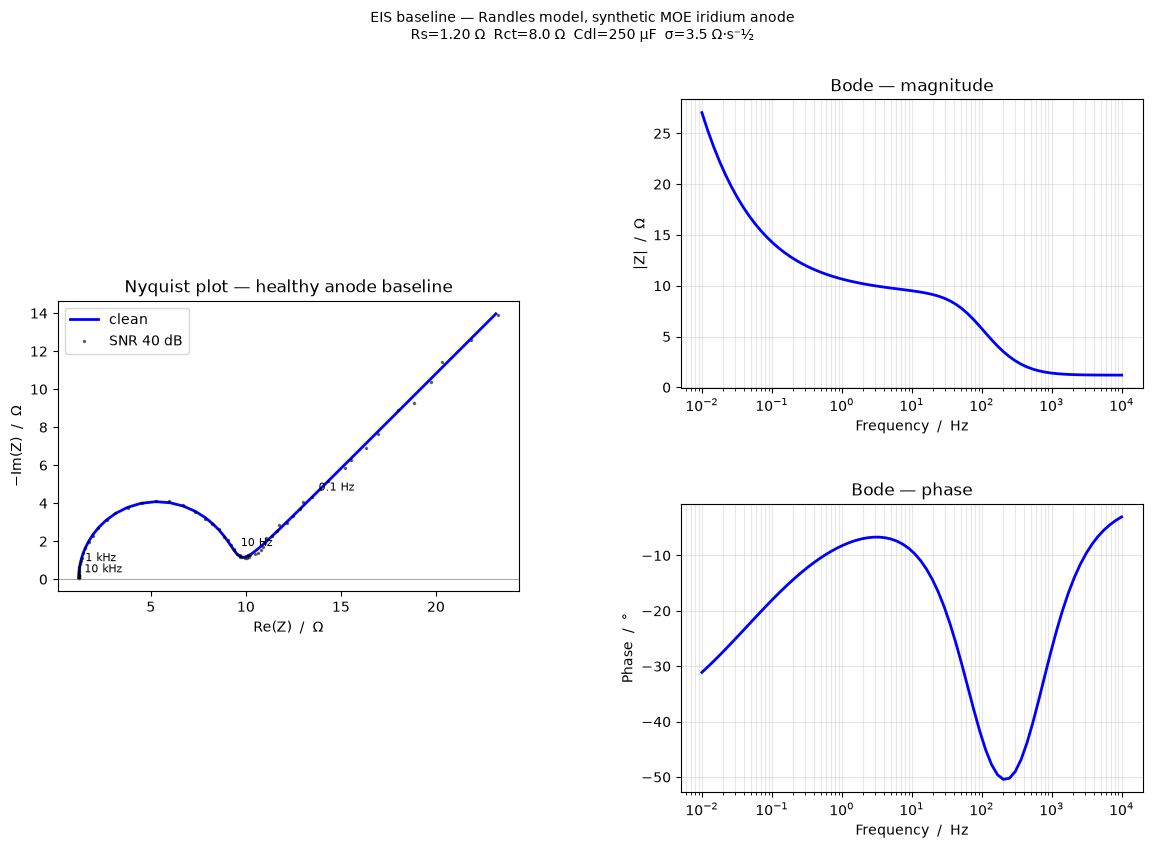

In [3]:
fig = plt.figure(figsize=(14, 9))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# ── Nyquist ──────────────────────────────────────────────────────────────────
ax_ny = fig.add_subplot(gs[:, 0])
re_c, nim_c = nyquist_arrays(Z_clean)
re_n, nim_n = nyquist_arrays(Z_noisy)

ax_ny.plot(re_c, nim_c, 'b-', lw=2, label='clean')
ax_ny.plot(re_n, nim_n, 'k.', ms=3, alpha=0.5, label='SNR 40 dB')

# Annotate key frequencies
for f_label, f_val in [("10 kHz", 1e4), ("1 kHz", 1e3), ("10 Hz", 10), ("0.1 Hz", 0.1)]:
    idx = np.argmin(np.abs(freqs - f_val))
    ax_ny.annotate(f_label, xy=(re_c[idx], nim_c[idx]), fontsize=8,
                   xytext=(re_c[idx]+0.3, nim_c[idx]+0.3))

ax_ny.axhline(0, color='grey', lw=0.5)
ax_ny.set_xlabel('Re(Z)  /  Ω')
ax_ny.set_ylabel('−Im(Z)  /  Ω')
ax_ny.set_title('Nyquist plot — healthy anode baseline')
ax_ny.legend()
ax_ny.set_aspect('equal')

# ── Bode magnitude ────────────────────────────────────────────────────────────
ax_bm = fig.add_subplot(gs[0, 1])
_, Z_mag, _ = bode_arrays(Z_clean, freqs)
ax_bm.semilogx(freqs, Z_mag, 'b-', lw=2)
ax_bm.set_xlabel('Frequency  /  Hz')
ax_bm.set_ylabel('|Z|  /  Ω')
ax_bm.set_title('Bode — magnitude')
ax_bm.grid(True, which='both', alpha=0.3)

# ── Bode phase ────────────────────────────────────────────────────────────────
ax_bp = fig.add_subplot(gs[1, 1])
_, _, Z_phase = bode_arrays(Z_clean, freqs)
ax_bp.semilogx(freqs, Z_phase, 'b-', lw=2)
ax_bp.set_xlabel('Frequency  /  Hz')
ax_bp.set_ylabel('Phase  /  °')
ax_bp.set_title('Bode — phase')
ax_bp.grid(True, which='both', alpha=0.3)

fig.suptitle(
    'EIS baseline — Randles model, synthetic MOE iridium anode\n'
    f'Rs={baseline.Rs:.2f} Ω  Rct={baseline.Rct:.1f} Ω  '
    f'Cdl={baseline.Cdl*1e6:.0f} μF  σ={baseline.sigma:.1f} Ω·s⁻½',
    fontsize=10
)
plt.savefig('../figures/01-randles-baseline.png', dpi=150, bbox_inches='tight')
plt.show()

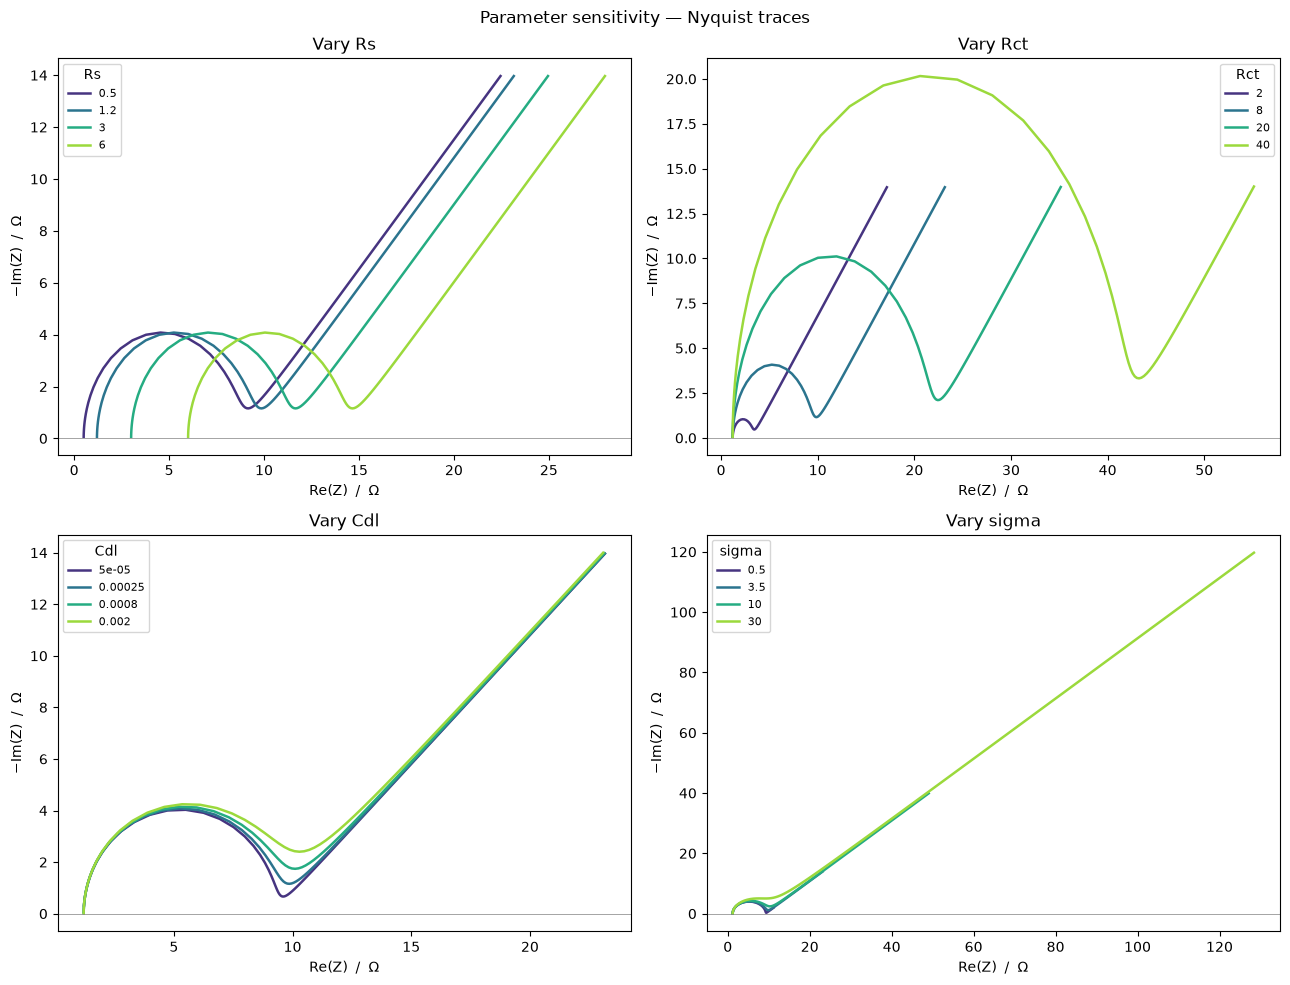

In [4]:
# ── Sensitivity: vary one parameter at a time ─────────────────────────────────
param_sweeps = {
    'Rs':    [0.5, 1.2, 3.0, 6.0],
    'Rct':   [2.0, 8.0, 20.0, 40.0],
    'Cdl':   [5e-5, 2.5e-4, 8e-4, 2e-3],
    'sigma': [0.5, 3.5, 10.0, 30.0],
}
colors = plt.cm.viridis(np.linspace(0.15, 0.85, 4))

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.ravel()

for ax, (param_name, values) in zip(axes, param_sweeps.items()):
    for val, col in zip(values, colors):
        p = baseline.copy(**{param_name: val})
        Z = randles_impedance(p, freqs)
        re, nim = nyquist_arrays(Z)
        unit = 'Ω' if 'R' in param_name or 's' in param_name else ('F' if 'C' in param_name else 'Ω·s⁻½')
        ax.plot(re, nim, color=col, lw=1.8, label=f'{val:.2g}')
    ax.set_xlabel('Re(Z)  /  Ω'); ax.set_ylabel('−Im(Z)  /  Ω')
    ax.set_title(f'Vary {param_name}')
    ax.legend(title=param_name, fontsize=8)
    ax.axhline(0, color='grey', lw=0.5)

fig.suptitle('Parameter sensitivity — Nyquist traces', fontsize=12)
plt.tight_layout()
plt.savefig('../figures/01-parameter-sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()